# Estimating Time-Varying Relationships

In [2]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.signal import convolve

Neural responses to events are not instantaneous — they occur with a certain latency and then taper off. To allow our regression to account for the temporal properties of the neural response, we must model the relationship between the events and neural response across multiple time-lags. This is achieved by creating a time-lagged matrix where each column is a copy of the events shifted by one sample. By regressing this matrix against the neural response, we'll obtain a list of $\beta$ weights, each of which describes the relationship between events and response at a given time lag.

Because these weights characterize the temporal properties of the neural response they are often referred to as temporal response functions (TRFs). In this lesson, you'll learn how to estimate TRFs on simulated data. The notebook proceeds as follows:
1. First, you are going to see how to create and visualize time-lagged matrices for one or multiple events
2. Using the time-lagged matrix, you are going to estimate TRFs using one or multiple features
3. With the estimated TRFs, you are going to predict the neural response and evaluate model accuracy using different metrics
4. Finally, you'll see how to use cross-validation to optimize the model

## Utility Functions

In [3]:
def _gen_impulses(fs, dur, isi, height=1, jitter=0):
    rng = np.random.default_rng(11)
    n = int(dur*fs)
    isis = np.atleast_1d(isi)
    X = np.zeros((n, len(isis)))
    for i, isi in enumerate(isis):
        t_event = np.arange(isi, dur, isi)
        t_event += rng.uniform(-jitter, jitter, t_event.size)
        idx = (t_event * fs).astype(int)
        idx = idx[(idx >= 0) & (idx < n)]
        h = height if not isinstance(height, list) else height[i]
        X[idx, i] = h
    t = np.linspace(0, dur, n)
    return X, t

def _gen_trf(fs, dur, peak, width):
    peaks = np.atleast_1d(peak)
    trf = np.zeros((int(fs*dur), len(peaks)))
    t = np.linspace(0, dur, int(dur*fs))
    for i, peak in enumerate(peaks):
        w = width if not isinstance(width, list) else width[i]
        trf[:,i] = np.exp(-((t - peak) ** 2) / (2 * w** 2))
    return trf, t

def _simulate_response(X, trf, noise_factor=1):
    rng = np.random.default_rng(11)
    y = np.zeros(len(X))
    for i in range(X.shape[1]):
        y += np.convolve(X[:, i], trf[:, i], mode="full")[:len(X)]
    y -= y.mean()
    y += rng.standard_normal(y.size)*noise_factor
    y = y[:, np.newaxis]
    return y

def _gen_lags(X, n_lags):
    n, k = X.shape
    X_lag = np.zeros((n, k * n_lags))
    for lag in range(n_lags):
        X_lag[lag:, lag*k:(lag+1)*k] = X[:n-lag]
    return X_lag

def _fit_lag_regression(X, y, fs, n_lags, lam=0):
    n_features = X.shape[1]
    X_lag = _gen_lags(X, n_lags)
    X_lag = np.hstack((np.ones((len(X_lag), 1)), X_lag))
    I = np.eye(X_lag.shape[1])
    I[0, 0] = 0
    coef = np.linalg.solve(X_lag.T @ X_lag + lam * I, X_lag.T @ y)
    t_lags = np.arange(n_lags) / fs
    beta = coef[1:].reshape(n_lags, n_features)
    return beta, coef[0], t_lags

def _pearsonr(y, y_pred):
    y = y - y.mean()
    y_pred = y_pred - y_pred.mean()
    return np.sum(y * y_pred) / np.sqrt(np.sum(y**2) * np.sum(y_pred**2))

def _rsquared(y, y_pred):
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1 - ss_res / ss_tot


def _crossval_lambda(X, y, fs, n_lags, lambdas, metric, n_folds=5):

    scores = np.zeros((len(lambdas), n_folds))
    Xs, ys = np.array_split(X, n_folds), np.array_split(y, n_folds)

    for i in range(n_folds):
        X_test, y_test = Xs[i], ys[i]
        X_train = np.concatenate([Xs[j] for j in range(n_folds) if j != i])
        y_train = np.concatenate([ys[j] for j in range(n_folds) if j != i])

        for k, lam in enumerate(lambdas):
            beta, alpha, _ = _fit_lag_regression(X_train, y_train, fs, n_lags, lam=lam)
            y_pred = convolve(X_test, beta, mode="full")[:len(y_test)] + alpha
            scores[k, i] = metric(y_test, y_pred)

    return scores

class utils:
    gen_trf = _gen_trf
    gen_impulses = _gen_impulses
    gen_lags = _gen_lags
    simulate_response = _simulate_response
    fit_lag_regression = _fit_lag_regression
    pearsonr = _pearsonr
    rsquared = _rsquared
    crossval_lambda = _crossval_lambda

## Creating a Time-Lagged Design Matrix

### Background

To allow our model to account for the temporal dynamics of the neural response, we do not simply use the event onsets as predictors but instead create a **time-lagged design matrix**.

This matrix is created by stacking time-shifted copies of $X$ column-wise, where each copy is offset by one additional sample. The resulting matrix has shape `(n_samples, n_features × n_lags)`. Regressing the neural signal $y$ onto it yields coefficients that describe the contribution of the stimulus at each time lag.

### Exercises

In the following exercises you are going to practice creating the time-lagged design matrix for different impulse-like events. You are going to inspect the shape of the matrix and visualize it as an image to get a feeling for how it is structured. Here are the relevant code examples:

| Code | Description |
| --- | --- |
| `X, t = utils.gen_impulses(fs, dur=1.5, isi=0.2)` | Generate a 1.5-second sequence of impulses at sampling rate `fs` with 0.2-second inter-stimulus intervals |
| `X_lag = utils.gen_lags(X, n_lags=15)` | Generate a time-lagged design matrix with 15 time lags of `X` |
| `plt.imshow(X, aspect="auto")` | Plot `X` as an image with automatic axis scaling |

The cell below generates an array of impulses at a sampling rate of 100 Hz. These could represent events in the experiment like the onsets of a stimulus.

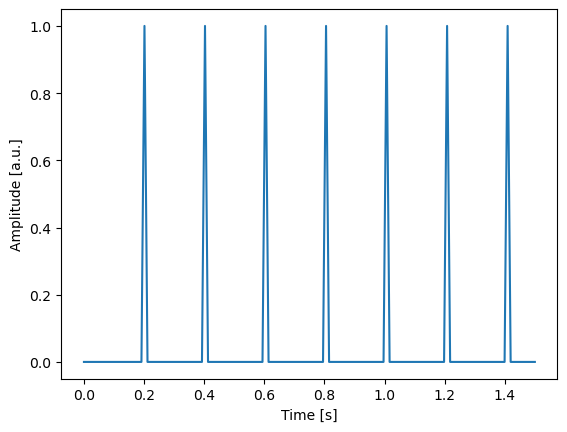

In [4]:
fs = 100
X, t = utils.gen_impulses(fs, dur=1.5, isi=0.2)
plt.plot(t, X);
plt.xlabel("Time [s]")
plt.ylabel('Amplitude [a.u.]');

**Example**: Generate the time-lagged matrix `X_lag` with `n_lags=5` and print its shape.

In [5]:
X_lag = utils.gen_lags(X, n_lags=5)
X_lag.shape

(150, 5)

**Exercise**: Generate the time-lagged matrix `X_lag` with `n_lags=9`. What is the shape of `X_lag`?

In [6]:
X_lag = utils.gen_lags(X, n_lags=9)
X_lag.shape

(150, 9)

**Exercise**: Use `plt.imshow()` with `aspect="auto"` to plot `X_lag` as an image.

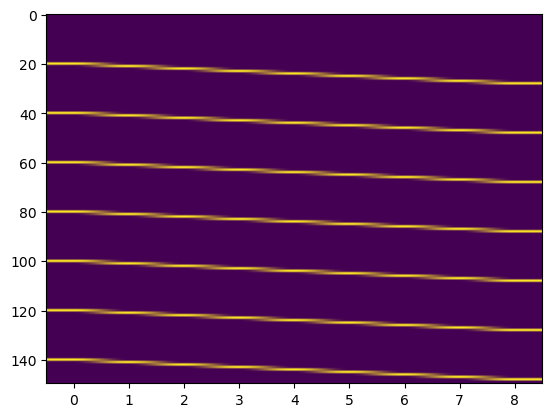

In [7]:
plt.imshow(X_lag, aspect="auto");

**Exercise**: Generate the time-lagged matrix `X_lag` with `n_lags=20` and plot it as an image.

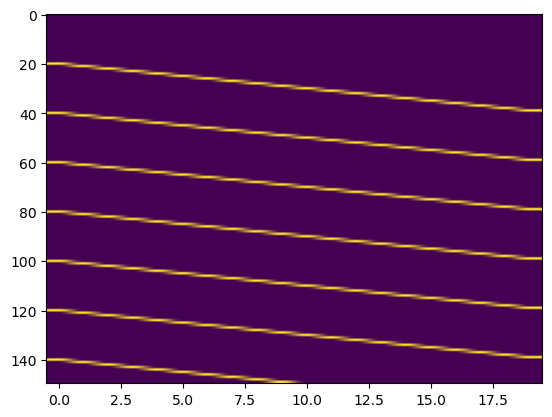

In [8]:
X_lag = utils.gen_lags(X, n_lags=20)
plt.imshow(X_lag, aspect="auto");

The cell below generates a matrix with two kinds of impulses at a sampling rate of 100 Hz. These could represent different events in the experiment like the onsets of a stimulus and the participant's response.

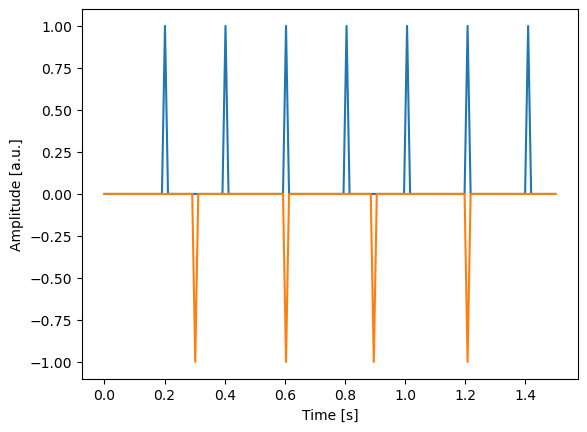

In [9]:
X, t = utils.gen_impulses(fs=100, dur=1.5, isi=[0.2, 0.3], height=[1, -1])
plt.plot(t, X);
plt.xlabel("Time [s]")
plt.ylabel("Amplitude [a.u.]");

**Exercise**: Generate the time-lagged matrix `X_lag` with `n_lags=15`. What is the shape of `X_lag`?

In [10]:
X_lag = utils.gen_lags(X, n_lags=15)
X_lag.shape

(150, 30)

**Exercise**: Plot `X_lag` as an image. Can you see which elements of the matrix correspond to the different events?

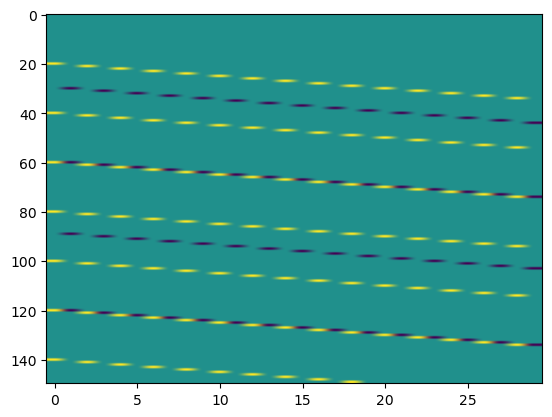

In [11]:
plt.imshow(X_lag, aspect="auto", interpolation=None);

The cell below generates a matrix with 4 different kinds of impulses.

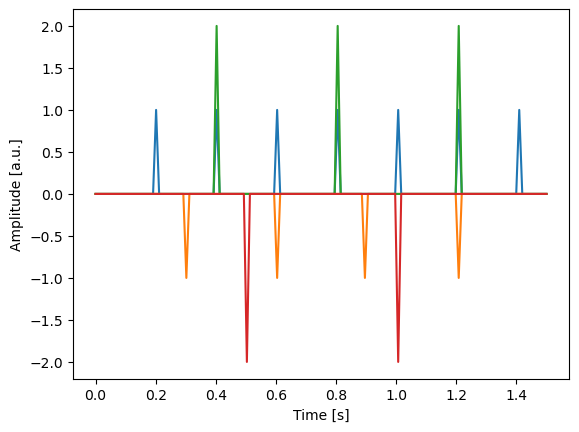

In [12]:
X, t = utils.gen_impulses(fs=100, dur=1.5, isi=[0.2, 0.3, 0.4, 0.5], height=[1, -1, 2, -2])
plt.plot(t, X);
plt.xlabel("Time [s]")
plt.ylabel("Amplitude [a.u.]");

**Exercise**: Generate the time-lagged matrix `X_lag` with `n_lags=12`. What is the shape of `X_lag`?

In [13]:
X_lag = utils.gen_lags(X, n_lags=12)
X_lag.shape

(150, 48)

**Exercise**: Plot `X_lag` as an image. Can you identify the 4 different types of events?

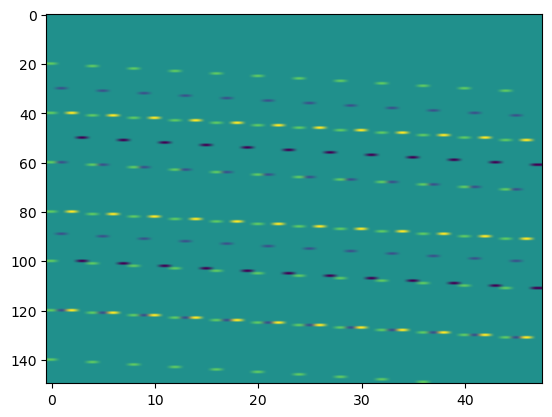

In [14]:
plt.imshow(X_lag, aspect="auto");

## Time-Lagged Regression

### Background

Now we can apply a linear model of the form $y = X_{lag} \beta + \alpha$ where $X_{lag}$ is the time-lagged stimulus matrix you learned about in the previous section. By fitting this model, we'll obtain a $\beta$ coefficient for every stimulus feature and every time lag, and an intercept $\alpha$. Because these weights describe the relationship between $X$ and $y$ they are often referred to as temporal response functions (TRF).

In this section we are going to use time-lagged regression to estimate the TRF for simulated data. In the simulations, neural responses are generated by convolving impulse-like events with a kernel. This kernel is the true TRF that was used for generating the data and our goal is to recover the true TRF from the noisy neural recording. There may be multiple types of events and not every event may be associated with the response. This is akin to real data analysis in neuroscience where we often have multiple predictors but can't be sure which ones are truly related to the neural response.

### Exercises

In this section you are going to fit time-lagged regression on simulated data. For this you are going to use the function `utils.fit_lag_regression` which automatically creates the time-lagged matrix and returns an array of `beta` coefficients shaped `(n_lags, n_features)`, the intercept `alpha`, and the time axis `t_lags`. The code is very similar across all exercises in this notebook so you can focus on interpreting the results and understanding the behavior of time-lagged linear models.

| Code | Description |
| --- | --- |
| `X, t = utils.gen_impulses(fs, dur=60, isi=0.2, jitter=0.05)` | Generate a 60-second sequence of jittered impulses at sampling rate `fs` with 0.2-second inter-stimulus intervals |
| `trf, t_trf = utils.gen_trf(fs, dur=0.3, peak=0.1, width=0.03)` | Generate a TRF with a duration of 0.3 seconds that peaks at 0.1 seconds with a width of 0.03 seconds |
| `y = utils.simulate_response(X, trf)` | Simulate a neural response by convolving `X` with `trf` and adding noise |
| `beta, alpha, t_lags = utils.fit_lag_regression(X, y, fs, n_lags=30)` | Fit a time-lagged regression and return TRF coefficients `beta` of shape `(n_lags, n_features)`, intercept `alpha`, and time axis `t_lags` |
| `beta, alpha, t_lags = utils.fit_lag_regression(X, y, fs, n_lags=30, lam=1)` | Fit with ridge regularization using penalty `lam` |
| `X = np.hstack([X1, X2])` | Combine two event matrices column-wise |

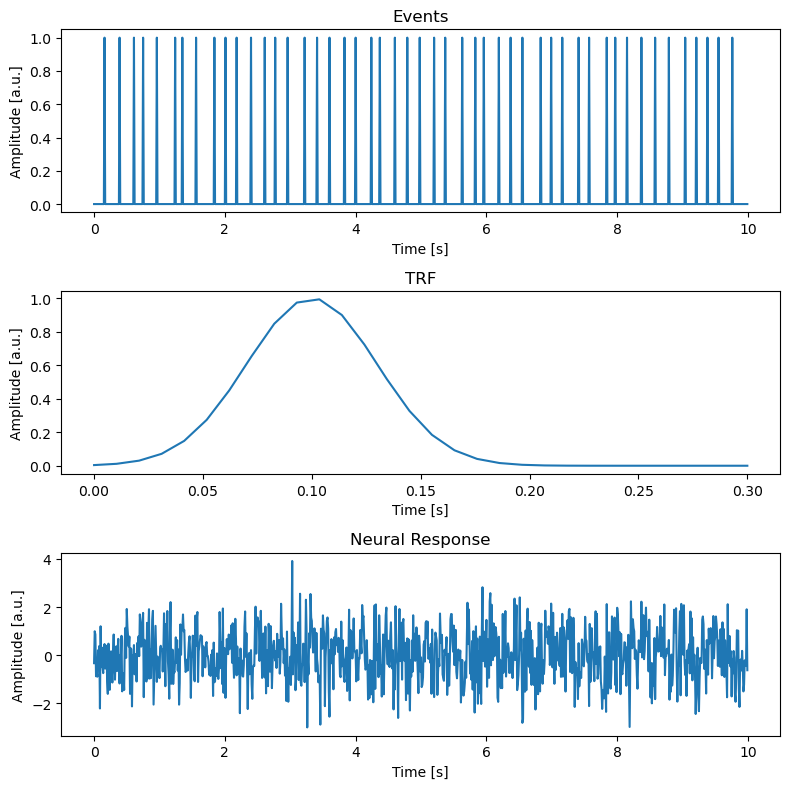

In [15]:
fs = 100
X, t = utils.gen_impulses(fs, dur=60, isi=0.2, jitter=0.05)
trf, t_trf = utils.gen_trf(fs, dur=0.3, peak=0.1, width=0.03)
y = utils.simulate_response(X, trf)

fig, ax = plt.subplots(3, figsize=(8,8))
ax[0].plot(t[:1000], X[:1000])
ax[0].set(title="Events", xlabel="Time [s]", ylabel="Amplitude [a.u.]")
ax[1].plot(t_trf, trf)
ax[1].set(title="TRF", xlabel="Time [s]", ylabel="Amplitude [a.u.]")
ax[2].plot(t[:1000], y[:1000])
ax[2].set(title="Neural Response", xlabel="Time [s]", ylabel="Amplitude [a.u.]")
plt.tight_layout()

**Example**: Fit a regression with `n_lags=10` and plot the returned `beta` coefficients together with the original TRF. Because the lags don't cover the full range of the original TRF, the reconstruction is truncated.

**Note**: The second value returned by `utils.fit_lag_regression()` is the intercept. Because we do not need it here, we'll assign it to the placeholder `_`.



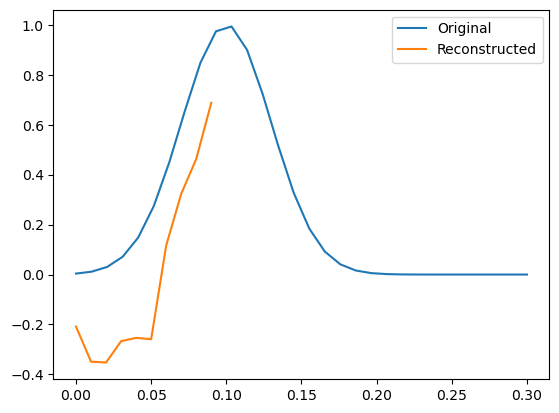

In [16]:
beta, _, t_lags = utils.fit_lag_regression(X, y, fs=100, n_lags=10)
plt.plot(t_trf, trf, label="Original")
plt.plot(t_lags, beta, label="Reconstructed")
plt.legend();

**Exercise**: Fit a regression with `n_lags=30` and plot the `beta` coefficients together with the original TRF. Does the amplitude of the reconstructed TRF match the original?

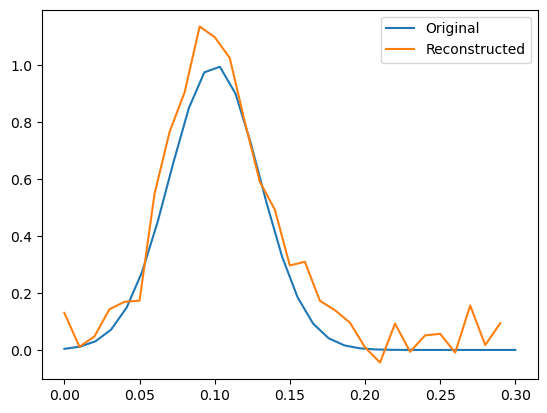

In [17]:
beta,_, t_lags = utils.fit_lag_regression(X, y, fs=100, n_lags=30)
plt.plot(t_trf, trf, label="Original")
plt.plot(t_lags, beta, label="Reconstructed")
plt.legend();

**Exercise**: Fit a regression with `n_lags=50` and plot the `beta` coefficients together with the original TRF (in reality, we do not know the length of the true TRF).

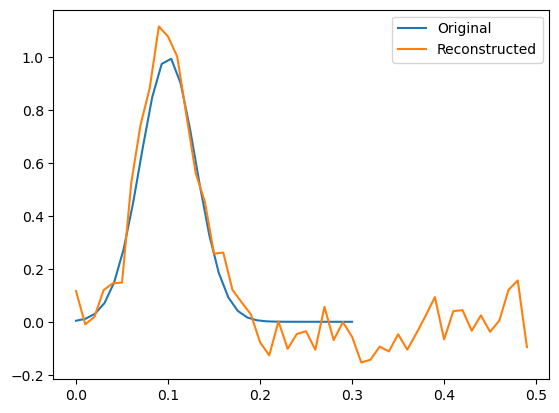

In [18]:
beta,_, t_lags = utils.fit_lag_regression(X, y, fs=100, n_lags=50)
plt.plot(t_trf, trf, label="Original")
plt.plot(t_lags, beta, label="Reconstructed")
plt.legend();

**Exercise**: Fit a regression with `n_lags=50` and set `lam=7` to use ridge regularization. Plot the `beta` coefficients together with the original TRF. Do the coefficients match now?

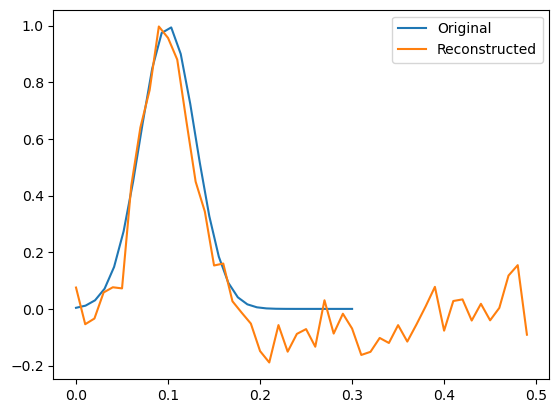

In [19]:
beta, _, t_lags = utils.fit_lag_regression(X, y, fs=100, n_lags=50, lam=7)
plt.plot(t_trf, trf, label="Original")
plt.plot(t_lags, beta, label="Reconstructed")
plt.legend();

**Exercise**: Increase the value of `lam` to 100. How does this affect the amplitude of the reconstructed TRF?

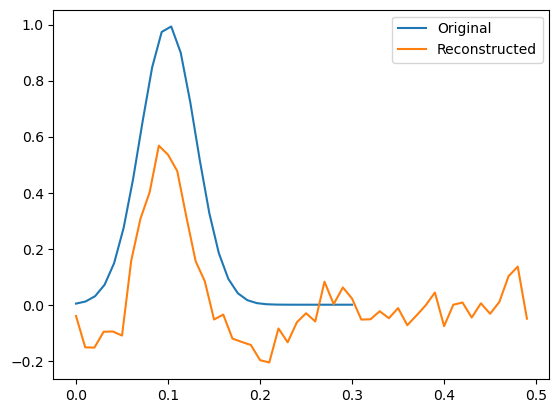

In [20]:
beta, _,  t_lags = utils.fit_lag_regression(X, y, fs=100, n_lags=50, lam=100)
plt.plot(t_trf, trf, label="Original")
plt.plot(t_lags, beta, label="Reconstructed")
plt.legend();

The cell below generates a new simulation where the neural response is the sum of two kinds of events and TRFs. Let's see if time-lagged regression can recover more than one TRF.

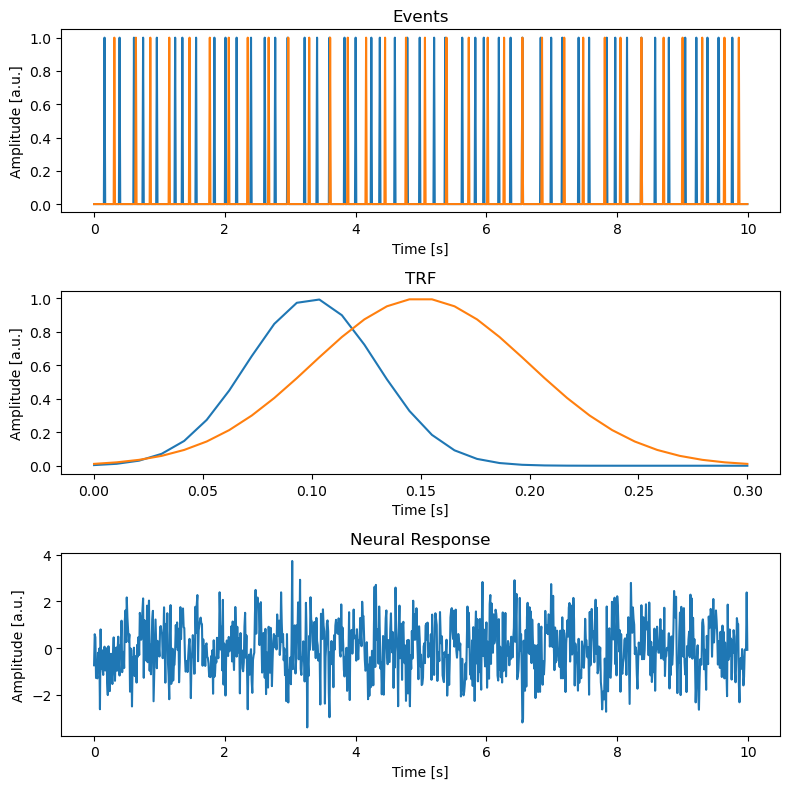

In [21]:
fs = 100
X, t = utils.gen_impulses(fs, dur=120, isi=[0.2, 0.3], jitter=0.05)
trf, t_trf = utils.gen_trf(fs, dur=0.3, peak=[0.1, 0.15], width=[0.03, 0.05])
y = utils.simulate_response(X, trf)

fig, ax = plt.subplots(3, figsize=(8,8))
ax[0].plot(t[:1000], X[:1000])
ax[0].set(title="Events", xlabel="Time [s]", ylabel="Amplitude [a.u.]")
ax[1].plot(t_trf, trf)
ax[1].set(title="TRF", xlabel="Time [s]", ylabel="Amplitude [a.u.]")
ax[2].plot(t[:1000], y[:1000])
ax[2].set(title="Neural Response", xlabel="Time [s]", ylabel="Amplitude [a.u.]")
plt.tight_layout()


**Exercise**: Fit a regression and plot the `beta` coefficients together with the original TRF. Can you recover both TRFs accurately?

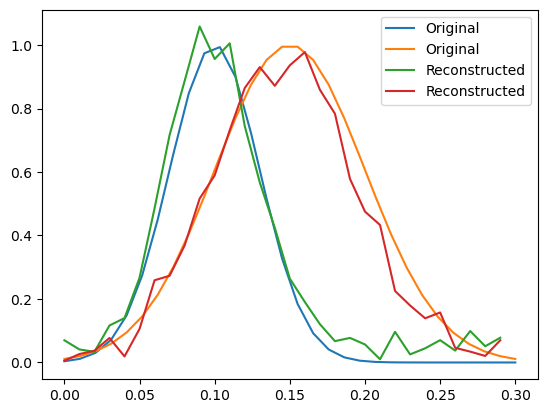

In [22]:
beta, _, t_lags = utils.fit_lag_regression(X, y, fs=100, n_lags=30, lam=3)
plt.plot(t_trf, trf, label="Original")
plt.plot(t_lags, beta, label="Reconstructed")
plt.legend();

The cell below generates a new simulation with two kinds of events `X1` and `X2` which are correlated but not identical. However, only `X1` is actually associated with the neural response via a TRF. Let's try to reconstruct the TRF from both events.

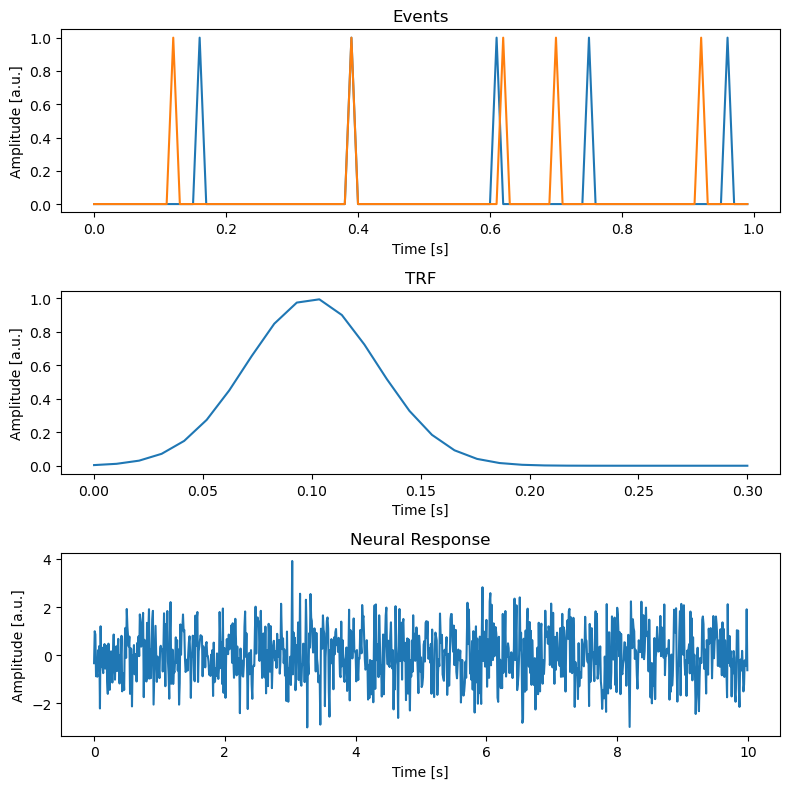

In [23]:
X1, t = utils.gen_impulses(fs, dur=60, isi=0.2, jitter=0.05)
X2, t = utils.gen_impulses(fs, dur=60, isi=0.2, jitter=0.1)
trf, t_trf = utils.gen_trf(fs, dur=0.3, peak=0.1, width=0.03)
y = utils.simulate_response(X1, trf)

fig, ax = plt.subplots(3, figsize=(8,8))
ax[0].plot(t[:100], X1[:100])
ax[0].plot(t[:100], X2[:100])
ax[0].set(title="Events", xlabel="Time [s]", ylabel="Amplitude [a.u.]")
ax[1].plot(t_trf, trf)
ax[1].set(title="TRF", xlabel="Time [s]", ylabel="Amplitude [a.u.]")
ax[2].plot(t[:1000], y[:1000])
ax[2].set(title="Neural Response", xlabel="Time [s]", ylabel="Amplitude [a.u.]")
plt.tight_layout()

**Exercise**: Fit a regression with `X1` (which is associated with the neural response) and plot the `beta` coefficients together with the original TRF. Choose `n_lags` and `lam` as you see fit.

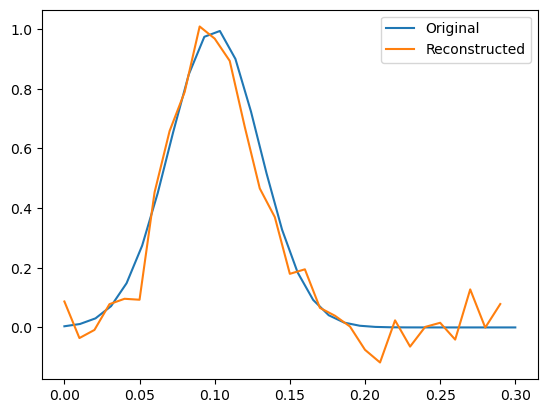

In [24]:
beta, _, t_lags = utils.fit_lag_regression(X1, y, fs=100, n_lags=30, lam=7)
plt.plot(t_trf, trf, label="Original")
plt.plot(t_lags, beta, label="Reconstructed")
plt.legend();

**Exercise**: Now fit a regression with `X2` (which is NOT associated with the neural response but correlated with `X1`) and plot the `beta` coefficients together with the original TRF. Does the reconstructed TRF resemble the original?

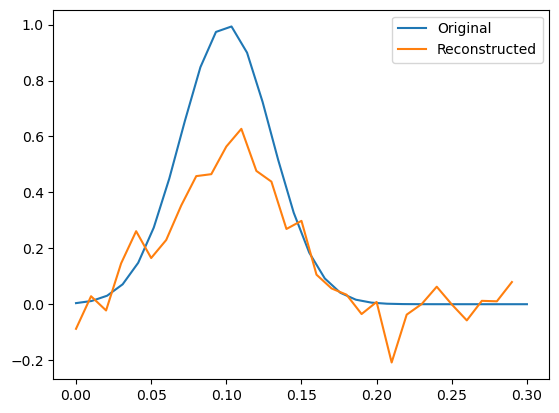

In [25]:
beta, _, t_lags = utils.fit_lag_regression(X2, y, fs=100, n_lags=30, lam=7)
plt.plot(t_trf, trf, label="Original")
plt.plot(t_lags, beta, label="Reconstructed")
plt.legend();

**Exercise**: The cell below stacks `X1` and `X2` into a single matrix `X`. Use `X` to fit a regression and plot the estimated `beta` coefficients together with the original TRF. Did the model correctly identify which event is actually associated with the response?

In [26]:
X = np.hstack([X1, X2])

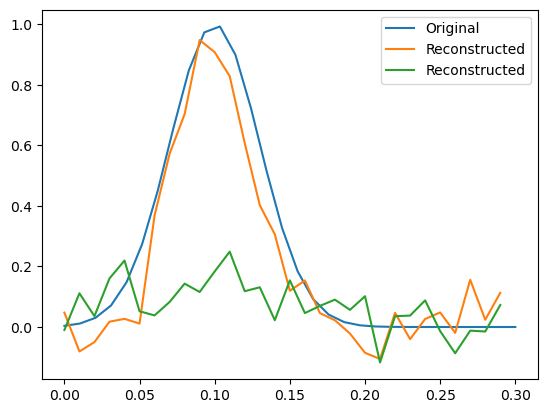

In [27]:
beta, _, t_lags = utils.fit_lag_regression(X, y, fs=100, n_lags=30, lam=0.1)
plt.plot(t_trf, trf, label="Original")
plt.plot(t_lags, beta, label="Reconstructed")
plt.legend();

## Evaluating Model Accuracy

### Background

Plotting the predicted and actual responses gives a qualitative impression of model performance, but to compare models or quantify fit quality we need a numerical measure of accuracy. To evaluate a model's accuracy, we use the estimated coefficients to predict the response and compare the prediction to the original signal.

Two common metrics are **Pearson's correlation coefficient** $r$ and the **coefficient of determination** $R^2$. Both measure the correspondence between the predicted signal $\hat{y}$ and the actual signal $y$, but they differ in an important way: Pearson's $r$ is scale-invariant — it measures only the shape of the relationship, regardless of absolute amplitude. $R^2$, on the other hand, also penalizes differences in amplitude: a prediction with the right shape but wrong scale will result in a low $R^2$.

In EEG/MEG analysis, Pearson's $r$ is often preferred because the amplitude of the predicted response depends on the regularization strength and other analysis choices, making $R^2$ less informative as a standalone metric.

### Exercises

In the following exercises you are going to predict neural responses from the estimated TRF via **convolution** and evaluate the predictions using Pearson's $r$ and $R^2$. You will compare both metrics under different noise levels and regularization strengths. Here are the relevant code examples:

| Code | Description |
| --- | --- |
| `y_pred = convolve(X, beta, mode="full")[:len(y)] + alpha` | Predict the neural response by convolving `X` with `beta` and adding the intercept `alpha` |
| `utils.pearsonr(y, y_pred)` | Compute Pearson's correlation coefficient $r$ between `y` and `y_pred` |
| `utils.rsquared(y, y_pred)` | Compute the coefficient of determination $R^2$ between `y` and `y_pred` |

**Example**: The cell below simulates the neural response and fits a time-lagged regression (without regularization). Predict the neural response by convolving `X` with `beta` and adding the intercept `alpha` and plot the predicted response together with the original.

**Note**: Because the result of the convolution is longer than the original, it must be cropped to `[:len(y)]`.

In [28]:
fs = 100
X, t = utils.gen_impulses(fs, dur=60, isi=0.2, jitter=0.05)
trf, t_trf = utils.gen_trf(fs, dur=0.3, peak=0.1, width=0.03)
y = utils.simulate_response(X, trf, noise_factor=1)
beta, alpha, t_lag = utils.fit_lag_regression(X, y, fs, n_lags=30)

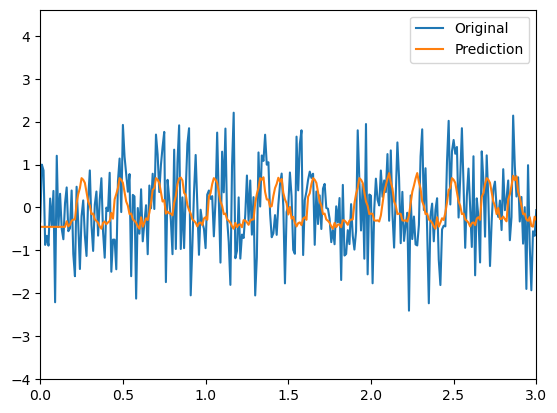

In [29]:
y_pred = convolve(X, beta, mode="full")[:len(y)] + alpha

plt.plot(t, y, label="Original")
plt.plot(t, y_pred, label="Prediction")
plt.legend()
plt.xlim(0, 3);

**Exercise**: The cell below recreates the simulation but reduces the amount of noise by an order of magnitude. Predict the neural response by convolving `X` with `beta` and adding the intercept `alpha` and plot the predicted response together with the original.

In [30]:
fs = 100
X, t = utils.gen_impulses(fs, dur=60, isi=0.2, jitter=0.05)
trf, t_trf = utils.gen_trf(fs, dur=0.3, peak=0.1, width=0.03)
y = utils.simulate_response(X, trf, noise_factor=0.1)
beta, alpha, t_lag = utils.fit_lag_regression(X, y, fs, n_lags=30)

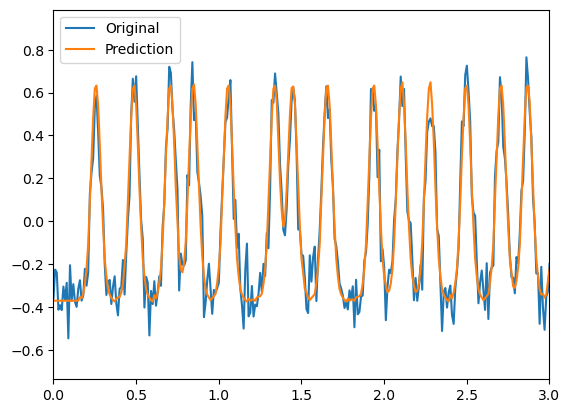

In [31]:
y_pred = convolve(X, beta, mode="full")[:len(y)] + alpha

plt.plot(t, y, label="Original")
plt.plot(t, y_pred, label="Prediction")
plt.legend()
plt.xlim(0, 3);

**Exercise**: Use `utils.pearsonr` and `utils.rsquared` to compute Pearson's correlation and the coefficient of determination $R^2$ for the original and the predicted response.

In [32]:
utils.pearsonr(y, y_pred), utils.rsquared(y, y_pred)

(np.float64(0.9626423800580801), np.float64(0.9266803518838854))

**Exercise**: The cell below recreates the simulation with a high noise level (`noise_factor=2`). Predict the neural response by convolving `X` with `beta` and adding the intercept `alpha` and compute Pearson's correlation and $R^2$ again. Which measure is more robust to noise?

In [33]:
fs = 100
X, t = utils.gen_impulses(fs, dur=60, isi=0.2, jitter=0.05)
trf, t_trf = utils.gen_trf(fs, dur=0.3, peak=0.1, width=0.03)
y = utils.simulate_response(X, trf, noise_factor=2)
beta, alpha, t_lag = utils.fit_lag_regression(X, y, fs, n_lags=30)

In [34]:
y_pred = convolve(X, beta, mode="full")[:len(y)] + alpha
utils.pearsonr(y, y_pred), utils.rsquared(y, y_pred)

(np.float64(0.20601719340191074), np.float64(0.04244308397720031))

Because ridge regularization shrinks the regression weights, it affects the scale of the model's output. Let's explore how increasing $\lambda$ affects the model predictions and accuracy metrics.

**Example**: The cell below recreates the simulation with a small amount of noise. Fit a regularized regression with `lam=1` and predict the response from the estimated coefficients. Compute Pearson's r and $R^2$ and plot the results.

In [35]:
fs = 100
X, t = utils.gen_impulses(fs, dur=60, isi=0.2, jitter=0.05)
trf, t_trf = utils.gen_trf(fs, dur=0.3, peak=0.1, width=0.03)
y = utils.simulate_response(X, trf, noise_factor=0.1)

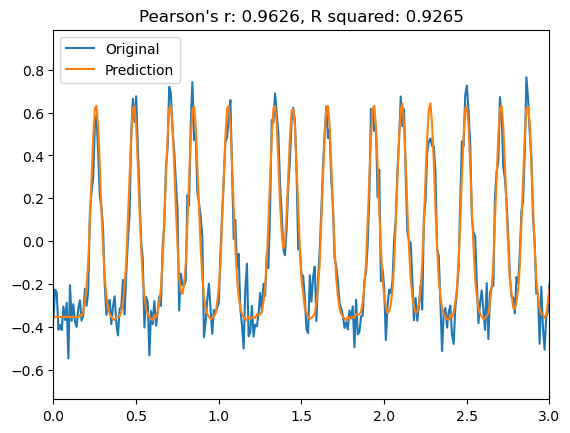

In [36]:
beta, alpha, t_lag = utils.fit_lag_regression(X, y, fs, n_lags=30, lam=1)
y_pred = convolve(X, beta, mode="full")[:len(y)] + alpha

plt.plot(t, y, label="Original")
plt.plot(t, y_pred, label="Prediction")
plt.title(f"Pearson's r: {utils.pearsonr(y, y_pred).round(4)}, R squared: {utils.rsquared(y, y_pred).round(4)}")
plt.legend()
plt.xlim(0, 3);

**Exercise**: Increase the value of `lam` to 1000. How does this affect the prediction? Did increasing the regularization result in a meaningful change of Pearson's $r$ and/or $R^2$?

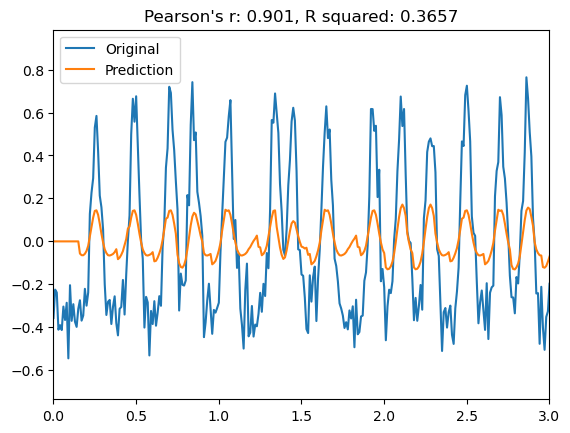

In [37]:
beta, alpha, t_lag = utils.fit_lag_regression(X, y, fs, n_lags=30, lam=1000)
y_pred = convolve(X, beta, mode="full")[:len(y)] + alpha
plt.plot(t, y, label="Original")
plt.plot(t, y_pred, label="Prediction")
plt.title(f"Pearson's r: {utils.pearsonr(y, y_pred).round(4)}, R squared: {utils.rsquared(y, y_pred).round(4)}")
plt.legend()
plt.xlim(0, 3);

## Cross-Validation

### Background

So far we have used regularization to prevent overfitting, but we have not yet addressed how to choose the regularization parameter $\lambda$. A common approach is **cross-validation**: the data is split into $k$ contiguous folds, and for each fold the model is trained on the remaining folds and evaluated on the held-out fold. By repeating this for all folds and averaging the scores, we get an estimate of how well the model generalizes to unseen data. The value of $\lambda$ that maximizes the cross-validated score is then used to fit the final model. Here, we use $k=5$ which is a typical choice for cross-validation.

When searching for the best model, the evaluation metric matters. Because Pearson's $r$ is scale-invariant, it produces a flat cross-validation curve that makes it difficult to identify the optimal $\lambda$. $R^2$ penalizes differences in amplitude and therefore provides a clearer optimization landscape. In practice it is common to select $\lambda$ using $R^2$ and then report Pearson's $r$ on the final model.

### Exercises

In the following exercises you are going to use cross-validation to select the regularization parameter $\lambda$ and explore how $\lambda$ is affected by the noise level and the number of time lags. Here are the relevant code examples:

| Code | Description |
| --- | --- |
| `scores = utils.crossval_lambda(X, y, fs, n_lags, lambdas, metric=utils.rsquared)` | Run 5-fold cross-validation for each value in `lambdas`, returns a `(n_lambdas, n_folds)` array of scores |
| `best_lambda = lambdas[np.argmax(scores.mean(axis=1))]` | Select the $\lambda$ with the highest mean cross-validated score |
| `lambdas = np.linspace(0, 8, 100)` | Generate 100 linearly-spaced values between 0 and 8 |
| `lambdas = np.logspace(-1, 3, 100)` | Generate 100 log-spaced values between $10^{-1}$ and $10^3$ |
| `plt.semilogx(lambdas, scores.mean(axis=1))` | Plot scores with a log-scaled x-axis |
| `plt.axvline(best_lambda, color="red", linestyle="--")` | Mark the best $\lambda$ with a vertical dashed line |

The cell below simulates some data. Let's use cross-validation to find the best value of $\lambda$ for our model.

In [38]:
fs = 100
X, t = utils.gen_impulses(fs, dur=10, isi=0.2, jitter=0.01)
trf, t_trf = utils.gen_trf(fs, dur=0.3, peak=0.1, width=0.03)
y = utils.simulate_response(X, trf, noise_factor=0.1)

**Example**: Use cross-validation to evaluate ridge regression with 30 time lags for 100 different `lambdas` between 0 and 2 using `utils.pearsonr` as the metric for evaluating accuracy and plot the result. The dashed line marks the $\lambda$ with the highest score.

<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
C:\Users\olebi\AppData\Local\Temp\ipykernel_11136\2226679860.py:7: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("$\lambda$")


Text(0, 0.5, "Pearson's r")

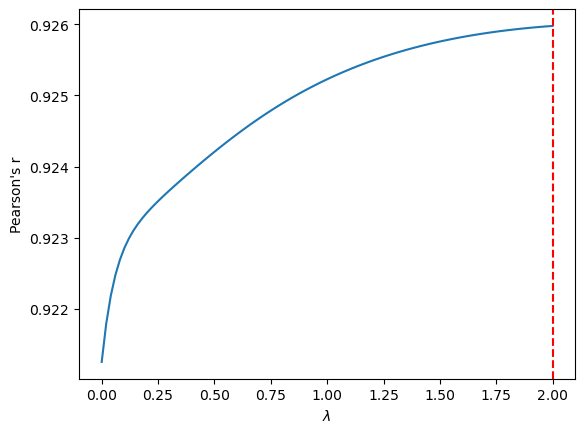

In [39]:
lambdas = np.linspace(0, 2, 100)
scores = utils.crossval_lambda(X, y, fs=100, n_lags=30, lambdas=lambdas, metric=utils.pearsonr)
best_lambda = lambdas[np.argmax(scores.mean(axis=1))]

plt.plot(lambdas, scores.mean(axis=1))
plt.axvline(best_lambda, color="red", linestyle="--")
plt.xlabel("$\lambda$")
plt.ylabel("Pearson's r")

**Exercise**: The previous example did not find the optimal value for $\lambda$. Increase the range of values, rerun the code and plot the result.

<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
C:\Users\olebi\AppData\Local\Temp\ipykernel_11136\1524163187.py:7: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("$\lambda$")


Text(0, 0.5, "Pearson's r")

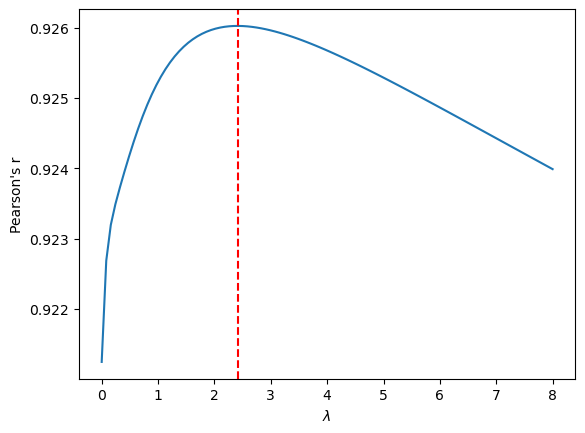

In [40]:
lambdas = np.linspace(0, 8, 100)
scores = utils.crossval_lambda(X, y, fs=100, n_lags=30, lambdas=lambdas, metric=utils.pearsonr)
best_lambda = lambdas[np.argmax(scores.mean(axis=1))]

plt.plot(lambdas, scores.mean(axis=1))
plt.axvline(best_lambda, color="red", linestyle="--")
plt.xlabel("$\lambda$")
plt.ylabel("Pearson's r")

**Exercise**: Rerun the cross-validation but use `utils.rsquared` as the evaluation `metric`. How does this affect the best value for $\lambda$?

<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
C:\Users\olebi\AppData\Local\Temp\ipykernel_11136\2036162210.py:7: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("$\lambda$")


Text(0, 0.5, '$R^2$')

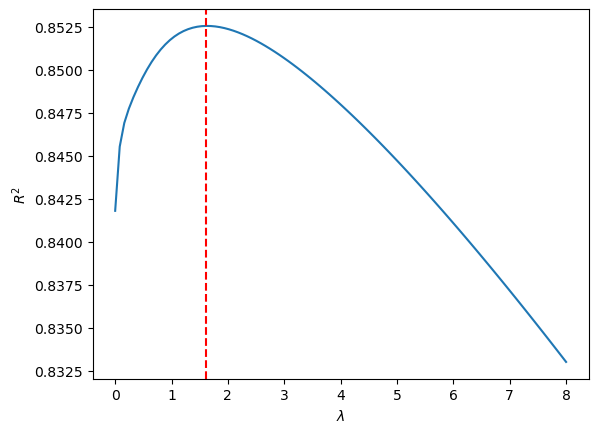

In [41]:
lambdas = np.linspace(0, 8, 100)
scores = utils.crossval_lambda(X, y, fs=100, n_lags=30, lambdas=lambdas, metric=utils.rsquared)
best_lambda = lambdas[np.argmax(scores.mean(axis=1))]

plt.plot(lambdas, scores.mean(axis=1))
plt.axvline(best_lambda, color="red", linestyle="--")
plt.xlabel("$\lambda$")
plt.ylabel("$R^2$")

**Exercise**: Rerun the cross-validation but increase the number of time lags to 50. How does increasing the number of lags affect the best value for $\lambda$? Does the result match your intuition?

<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
C:\Users\olebi\AppData\Local\Temp\ipykernel_11136\1109247047.py:7: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("$\lambda$")


Text(0, 0.5, '$R^2$')

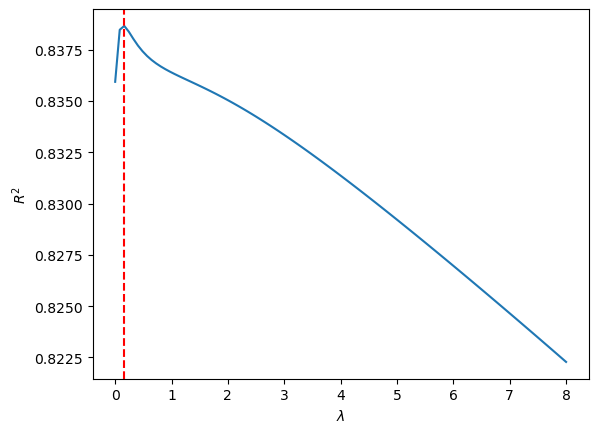

In [42]:
lambdas = np.linspace(0, 8, 100)
scores = utils.crossval_lambda(X, y, fs=100, n_lags=50, lambdas=lambdas, metric=utils.rsquared)
best_lambda = lambdas[np.argmax(scores.mean(axis=1))]

plt.plot(lambdas, scores.mean(axis=1))
plt.axvline(best_lambda, color="red", linestyle="--")
plt.xlabel("$\lambda$")
plt.ylabel("$R^2$")

EEG recordings usually have a low signal-to-noise ratio. Let's increase the amount of noise in the signal to see how this affects the best value for $\lambda$.

In [43]:
fs = 100
X, t = utils.gen_impulses(fs, dur=10, isi=0.2, jitter=0.01)
trf, t_trf = utils.gen_trf(fs, dur=0.3, peak=0.1, width=0.03)
y = utils.simulate_response(X, trf, noise_factor=2)

**Exercise**: Run cross-validation with `metric=utils.rsquared` and select the range of `lambdas` so you can find the optimal value for $\lambda$. 

**Tip**: Use `np.logspace()` to efficiently sample a large range of values and `plt.semilogx()` to log-scale the x-axis.

<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
C:\Users\olebi\AppData\Local\Temp\ipykernel_11136\1434723988.py:7: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("$\lambda$")


Text(0, 0.5, '$R^2$')

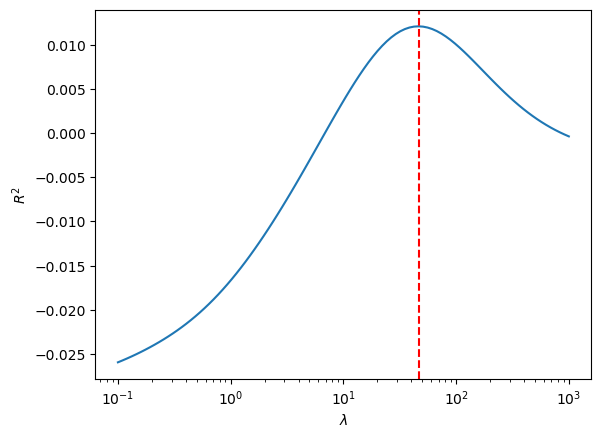

In [44]:
lambdas = np.logspace(-1, 3, 100)
scores = utils.crossval_lambda(X, y, fs=100, n_lags=30, lambdas=lambdas, metric=utils.rsquared)
best_lambda = lambdas[np.argmax(scores.mean(axis=1))]

plt.semilogx(lambdas, scores.mean(axis=1))
plt.axvline(best_lambda, color="red", linestyle="--")
plt.xlabel("$\lambda$")
plt.ylabel("$R^2$")

**Exercise**: Run cross-validation with `metric=utils.pearsonr`. Can you identify a clear plateau?

<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
C:\Users\olebi\AppData\Local\Temp\ipykernel_11136\924276181.py:7: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("$\lambda$")


Text(0, 0.5, "Pearson's r")

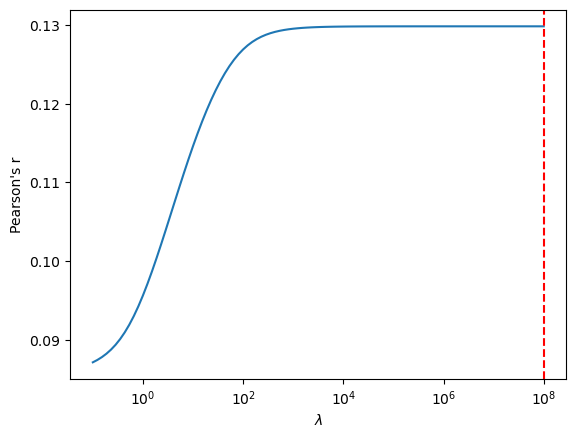

In [45]:
lambdas = np.logspace(-1, 8, 100)
scores = utils.crossval_lambda(X, y, fs=100, n_lags=30, lambdas=lambdas, metric=utils.pearsonr)
best_lambda = lambdas[np.argmax(scores.mean(axis=1))]

plt.semilogx(lambdas, scores.mean(axis=1))
plt.axvline(best_lambda, color="red", linestyle="--")
plt.xlabel("$\lambda$")
plt.ylabel("Pearson's r")